# VeritAI: treino e avaliação do modelo de relação trecho × afirmação

Na análise da VeritAI, cada afirmação de uma notícia é comparada com trechos de evidência. Até aqui essa comparação era feita por modelos prontos (embedding + NLI) e por limiares herdados do protótipo, que nunca foram validados.

Neste notebook treinamos um modelo que recebe um **trecho** e uma **afirmação** e estima a probabilidade de o trecho **apoiar** a afirmação. Depois comparamos esse modelo com os NLIs usados sem treino e com a regra atual do serviço.

**Dados:** ASSIN 2 (`nilc-nlp/assin2`), conjunto público em português do Brasil com pares de frases rotulados por pessoas como `ENTAILMENT` (a primeira frase implica a segunda) ou `NONE`. Usamos a divisão oficial: treino, validação e teste.

**Modelo:** regressão logística sobre atributos calculados pelos modelos da VeritAI (similaridade do embedding e probabilidades do NLI dos perfis v0 e v1) e por alguns sinais simples de texto.

**O que este notebook não mede:** o ASSIN 2 tem frases curtas e genéricas, não notícias. Os resultados valem para a etapa de relação trecho × afirmação, não para a VeritAI verificando notícias de verdade. O rótulo é binário, então "contradiz" e "não tem informação" ficam juntos em "não apoia". O modelo não entra na API e não libera porcentagem (`calibrado` continua `false` no `config.json`).

## Como rodar

Na raiz do repositório, com o ambiente virtual criado:

```
.venv\Scripts\python -m pip install -e ".[modelos,treino]"
.venv\Scripts\python -m jupyter notebook modelo/treinar_e_avaliar.ipynb
```

Depois é só executar as células em ordem (Kernel > Restart & Run All). Na primeira vez, o notebook baixa o ASSIN 2 para `data/assin2/` e os modelos do Hugging Face para o cache local. O cálculo dos atributos é a parte demorada: o NLI da v1 (mDeBERTa) é pesado na CPU, e na nossa máquina (CPU com 28 núcleos lógicos, sem GPU) levou cerca de 56 minutos para os 9.448 pares. O resultado fica salvo em `data/assin2/`, então as próximas execuções levam poucos segundos. O modelo treinado é salvo em `models/veritai_relacao_assin2.pkl`. As pastas `data/` e `models/` ficam fora do git.

**No Google Colab:** abra este notebook no Colab e execute a primeira célula de código. Ela pede o arquivo `veritai_colab.zip`, que traz o código da VeritAI e os atributos já calculados (sem eles, o Colab gratuito, com 2 núcleos, levaria horas no mDeBERTa). Depois disso, execute as demais células normalmente. Fora do Colab essa célula não faz nada.

In [1]:
# Só no Google Colab: recebe o código da VeritAI e os atributos já calculados.
import sys

if "google.colab" in sys.modules:
    import os
    import subprocess
    import zipfile

    from google.colab import files

    if not os.path.exists("/content/veritai/pyproject.toml"):
        enviado = files.upload()
        zipfile.ZipFile(next(iter(enviado))).extractall("/content/veritai")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "python-dotenv", "sentence-transformers", "pyarrow"], check=True)
    os.chdir("/content/veritai")
    sys.path.insert(0, "/content/veritai")

In [2]:
import os

os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("HF_HUB_VERBOSITY", "error")

import hashlib
import warnings
import json
import platform
import re
import time
import urllib.request
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import transformers
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from veritai.config import CONFIG, LIMIARES, perfil
from veritai.modelos import ModelosHF

warnings.filterwarnings("ignore", category=FutureWarning)
transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()

RAIZ = Path.cwd().parent if Path.cwd().name == "modelo" else Path.cwd()
DADOS = RAIZ / "data" / "assin2"
ARQUIVO_MODELO = RAIZ / "models" / "veritai_relacao_assin2.pkl"
SEMENTE = 42
PERFIS = ["v0", "v1"]

print("Python", platform.python_version(), "| torch", torch.__version__, "| transformers", transformers.__version__, "| scikit-learn", sklearn.__version__)
print("calibrado no config.json:", CONFIG["calibrado"])

Python 3.13.5 | torch 2.14.1+cpu | transformers 5.19.0 | scikit-learn 1.9.1
calibrado no config.json: False


## 1. Dados

Baixamos os três arquivos da divisão oficial. A coluna `premise` faz o papel do trecho de evidência e `hypothesis` o da afirmação, na mesma ordem em que o serviço manda os pares ao NLI. O rótulo `1` (`ENTAILMENT`) vira "apoia" e o `0` (`NONE`) vira "não apoia".

In [3]:
URL = "https://huggingface.co/datasets/nilc-nlp/assin2/resolve/refs%2Fconvert%2Fparquet/default/{}/0000.parquet"
PARTES = {"treino": "train", "validacao": "validation", "teste": "test"}

DADOS.mkdir(parents=True, exist_ok=True)
conjuntos, hashes = {}, {}
for nome, parte in PARTES.items():
    arquivo = DADOS / f"{parte}.parquet"
    if not arquivo.exists():
        urllib.request.urlretrieve(URL.format(parte), arquivo)
    hashes[nome] = hashlib.sha256(arquivo.read_bytes()).hexdigest()
    df = pd.read_parquet(arquivo)
    conjuntos[nome] = pd.DataFrame({
        "trecho": df["premise"],
        "afirmacao": df["hypothesis"],
        "apoia": df["entailment_judgment"].astype(int),
    })

pd.DataFrame({
    nome: {"pares": len(df), "apoia": int(df.apoia.sum()), "% apoia": round(100 * df.apoia.mean(), 1)}
    for nome, df in conjuntos.items()
}).T

,pares,apoia,% apoia
treino,6500.0,3250.0,50.0
validacao,500.0,250.0,50.0
teste,2448.0,1224.0,50.0


In [4]:
conjuntos["treino"].sample(6, random_state=SEMENTE)

,trecho,afirmacao,apoia
3106,Dois homens estão lutando em um pasto para vaca,Dois homens estão brigando em um pasto para vacas,1
6161,O homem é um tocador de violão,Um barco está calmamente velejando sobre a água,0
1867,"A mulher está alegremente tocando um violão, q...","A mulher está tocando um violão, que é acústic...",1
3238,A menina loira está dançando em frente ao equi...,O equipamento na frente da menina loira dançan...,1
5509,Dois homens com bicicletas estão do lado de um...,Dois homens estão segurando bicicletas e parad...,0
6167,O homem está jogando uma criança dentro de uma...,Um pai está tirando sua filha de uma piscina,0


Antes de treinar, conferimos se há pares ou frases repetidos entre as partes. Par repetido entre treino e teste seria vazamento. Frase de trecho repetida é comum no ASSIN 2 (a mesma frase aparece com várias afirmações), por isso a validação cruzada mais abaixo separa os grupos pelo trecho.

In [5]:
def pares(df):
    return set(zip(df.trecho, df.afirmacao))

for a, b in [("treino", "validacao"), ("treino", "teste"), ("validacao", "teste")]:
    print(f"{a} x {b}: {len(pares(conjuntos[a]) & pares(conjuntos[b]))} pares iguais, "
          f"{len(set(conjuntos[a].trecho) & set(conjuntos[b].trecho))} trechos iguais")
print("trechos distintos no treino:", conjuntos["treino"].trecho.nunique(), "de", len(conjuntos["treino"]))

treino x validacao: 11 pares iguais, 304 trechos iguais
treino x teste: 0 pares iguais, 685 trechos iguais
validacao x teste: 0 pares iguais, 111 trechos iguais
trechos distintos no treino: 3667 de 6500


## 2. Atributos

Para cada par calculamos:

- com cada perfil da VeritAI (v0 e v1): a similaridade do cosseno entre afirmação e trecho no embedding do perfil e as três probabilidades do NLI (apoio, neutro, contradição);
- sinais simples de texto: proporção de palavras em comum (Jaccard), quanto da afirmação aparece no trecho, negação presente em só um dos lados e razão entre os tamanhos.

Também testamos um atributo que marcava número presente na afirmação e ausente no trecho, pensando em notícias com valores e datas. No ASSIN 2 ele deu zero em todos os pares, porque o conjunto quase não tem números, e por isso foi retirado: com variância zero no treino, ele não teria peso nenhum.

Os modelos do perfil são os mesmos do serviço (`veritai.modelos.ModelosHF`), com os mesmos prefixos do e5 na v1. O resultado fica salvo em `data/assin2/` para não ser recalculado.

In [6]:
NEGACOES = {"não", "nem", "nunca", "jamais", "ninguém", "nenhum", "nenhuma", "nada"}


def palavras(texto):
    return re.findall(r"\w+", texto.lower())


def atributos_de_texto(trechos, afirmacoes):
    linhas = []
    for trecho, afirmacao in zip(trechos, afirmacoes):
        a, b = set(palavras(trecho)), set(palavras(afirmacao))
        linhas.append({
            "jaccard": len(a & b) / len(a | b) if a | b else 0.0,
            "cobertura_afirmacao": len(a & b) / len(b) if b else 0.0,
            "negacao_so_de_um_lado": float(bool(a & NEGACOES) != bool(b & NEGACOES)),
            "razao_tamanho": len(b) / max(len(a), 1),
        })
    return pd.DataFrame(linhas)


modelos = {nome: ModelosHF(nome) for nome in PERFIS}


def atributos_de_modelo(nome, trechos, afirmacoes, lote=64):
    m = modelos[nome]
    vetores_afirmacao = m.vetorizar(afirmacoes, "consulta")
    vetores_trecho = m.vetorizar(trechos, "trecho")
    probabilidades = []
    for i in range(0, len(trechos), lote):
        probabilidades += m.classificar(list(zip(trechos[i:i + lote], afirmacoes[i:i + lote])))
    return pd.DataFrame({
        f"{nome}_similaridade": (vetores_afirmacao * vetores_trecho).sum(axis=1),
        f"{nome}_apoio": [p["entailment"] for p in probabilidades],
        f"{nome}_neutro": [p["neutral"] for p in probabilidades],
        f"{nome}_contradicao": [p["contradiction"] for p in probabilidades],
    })


def calcular_atributos(trechos, afirmacoes):
    trechos, afirmacoes = list(trechos), list(afirmacoes)
    partes = [atributos_de_modelo(nome, trechos, afirmacoes) for nome in PERFIS]
    return pd.concat(partes + [atributos_de_texto(trechos, afirmacoes)], axis=1)


atributos = {}
for nome, df in conjuntos.items():
    arquivo = DADOS / f"atributos_{nome}.parquet"
    if arquivo.exists():
        atributos[nome] = pd.read_parquet(arquivo)
        print(f"{nome}: lidos do disco")
    else:
        inicio = time.perf_counter()
        atributos[nome] = calcular_atributos(df.trecho, df.afirmacao)
        atributos[nome].to_parquet(arquivo)
        print(f"{nome}: {len(df)} pares em {time.perf_counter() - inicio:.0f} s")

COLUNAS = list(atributos["treino"].columns)
atributos["treino"].describe().T.round(3)

treino: lidos do disco
validacao: lidos do disco
teste: lidos do disco


,count,mean,std,min,25%,50%,75%,max
v0_similaridade,6500.0,0.761,0.241,-0.184,0.631,0.847,0.951,1.000
v0_apoio,6500.0,0.547,0.432,0.000,0.039,0.686,0.989,0.995
v0_neutro,6500.0,0.151,0.288,0.001,0.005,0.015,0.095,0.995
v0_contradicao,6500.0,0.302,0.383,0.001,0.004,0.047,0.680,0.997
v1_similaridade,6500.0,0.894,0.037,0.750,0.871,0.902,0.923,0.956
v1_apoio,6500.0,0.448,0.432,0.000,0.010,0.295,0.951,1.000
v1_neutro,6500.0,0.314,0.363,0.000,0.015,0.111,0.625,1.000
v1_contradicao,6500.0,0.237,0.369,0.000,0.001,0.012,0.376,1.000
jaccard,6500.0,0.486,0.230,0.000,0.300,0.500,0.667,1.000
cobertura_afirmacao,6500.0,0.634,0.234,0.000,0.500,0.667,0.833,1.000


## 3. Linhas de base (sem treino)

Para saber se o treino ajuda, comparamos com três formas de decidir sem nenhum treino:

- **NLI v0 sem treino:** apoia quando o rótulo mais provável do NLI da v0 é `entailment`;
- **NLI v1 sem treino:** o mesmo com o NLI da v1 (mDeBERTa);
- **Regra atual da VeritAI (v0):** apoia quando a similaridade v0 é pelo menos `similaridade_forte` e a probabilidade de apoio é pelo menos `nli_forte`, os limiares que estão hoje no `config.json` e que nunca foram validados.

In [7]:
def decisao_nli(a, nome):
    return (a[f"{nome}_apoio"] >= a[[f"{nome}_neutro", f"{nome}_contradicao"]].max(axis=1)).astype(int).to_numpy()


def decisao_regra_atual(a):
    return ((a["v0_similaridade"] >= LIMIARES["similaridade_forte"]) & (a["v0_apoio"] >= LIMIARES["nli_forte"])).astype(int).to_numpy()


print("limiares atuais:", {chave: LIMIARES[chave] for chave in ("similaridade_forte", "nli_forte")})

limiares atuais: {'similaridade_forte': 0.43, 'nli_forte': 0.72}


## 4. Métricas

As mesmas que o projeto definiu para a VeritAI, adaptadas às duas classes:

- **macro-F1:** média do F1 de "apoia" e de "não apoia";
- **taxa de falsas aprovações:** entre os pares que **não** apoiam, a fração marcada como "apoia". É o erro mais grave para a VeritAI, porque leva o revisor a confiar numa afirmação sem base;
- acurácia, precisão e revocação de "apoia";
- **Brier** e **ECE** (erro de calibração em 10 faixas): dizem se a probabilidade estimada corresponde à frequência real;
- AUC da curva ROC;
- intervalo de 95% por bootstrap (1000 reamostragens dos pares do teste, semente fixa).

In [8]:
def falsas_aprovacoes(y, pred):
    return float(pred[y == 0].mean())


def ece(y, prob, faixas=10):
    indice = np.minimum((prob * faixas).astype(int), faixas - 1)
    return float(sum((indice == i).mean() * abs(y[indice == i].mean() - prob[indice == i].mean())
                     for i in range(faixas) if (indice == i).any()))


def metricas(y, pred, prob):
    return {
        "acuracia": accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "f1_apoia": f1_score(y, pred),
        "precisao_apoia": precision_score(y, pred, zero_division=0),
        "revocacao_apoia": recall_score(y, pred),
        "falsas_aprovacoes": falsas_aprovacoes(y, pred),
        "brier": brier_score_loss(y, prob),
        "ece": ece(y, prob),
        "auc": roc_auc_score(y, prob),
    }


def intervalo(y, pred, funcao, repeticoes=1000, semente=SEMENTE):
    sorteio = np.random.default_rng(semente)
    valores = []
    for _ in range(repeticoes):
        i = sorteio.integers(0, len(y), len(y))
        valores.append(funcao(y[i], pred[i]))
    return np.percentile(valores, [2.5, 97.5])

## 5. Treino

Regressão logística com padronização dos atributos. O único hiperparâmetro, a regularização `C`, é escolhido por validação cruzada de 5 partes **só no treino**, com os pares agrupados pelo trecho (`StratifiedGroupKFold`), para que a mesma frase não fique dos dois lados de uma divisão.

Escolhemos regressão logística porque é rápida na CPU, porque seus coeficientes mostram quanto cada atributo pesa e porque costuma produzir probabilidades razoáveis sem ajuste extra, o que importa para a calibração que o projeto exige antes de mostrar qualquer porcentagem.

In [9]:
X = {nome: atributos[nome][COLUNAS].to_numpy() for nome in conjuntos}
y = {nome: conjuntos[nome].apoia.to_numpy() for nome in conjuntos}

busca = GridSearchCV(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    scoring="f1_macro",
    cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEMENTE),
)
inicio = time.perf_counter()
busca.fit(X["treino"], y["treino"], groups=conjuntos["treino"].trecho)
print(f"treino em {time.perf_counter() - inicio:.1f} s")

pd.DataFrame({
    "C": busca.cv_results_["param_logisticregression__C"],
    "macro-F1 médio (validação cruzada)": busca.cv_results_["mean_test_score"].round(4),
    "desvio": busca.cv_results_["std_test_score"].round(4),
})

treino em 0.7 s


,C,macro-F1 médio (validação cruzada),desvio
0,0.001,0.8810,0.0052
1,0.010,0.8909,0.0059
2,0.100,0.8926,0.0061
3,1.000,0.8917,0.0065
4,10.000,0.8915,0.0064
5,100.000,0.8915,0.0064


C escolhido: 0.1


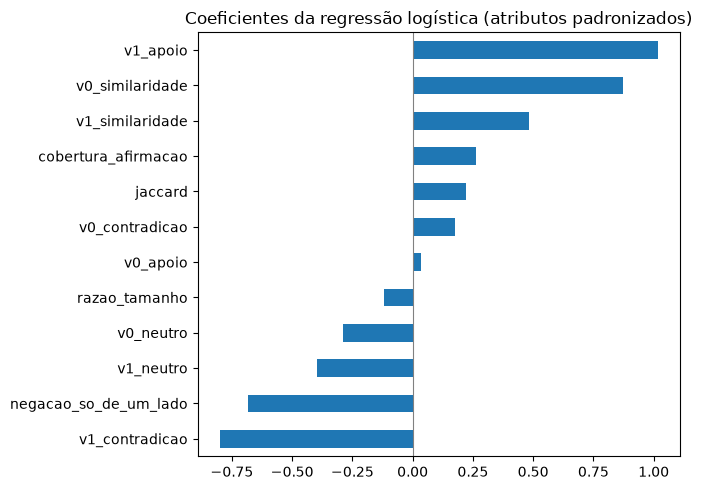

In [10]:
modelo = busca.best_estimator_
print("C escolhido:", busca.best_params_["logisticregression__C"])

coeficientes = pd.Series(modelo[-1].coef_[0], index=COLUNAS).sort_values()
coeficientes.plot.barh(figsize=(7, 5), title="Coeficientes da regressão logística (atributos padronizados)")
plt.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

### Limiar de decisão

A regressão devolve uma probabilidade. O limiar que transforma essa probabilidade em "apoia" é escolhido no conjunto de **validação** (500 pares que não entraram no treino), pelo maior macro-F1. O gráfico mostra também a taxa de falsas aprovações em cada limiar, porque um limiar mais alto troca revocação por menos falsas aprovações.

limiar escolhido na validação: 0.39


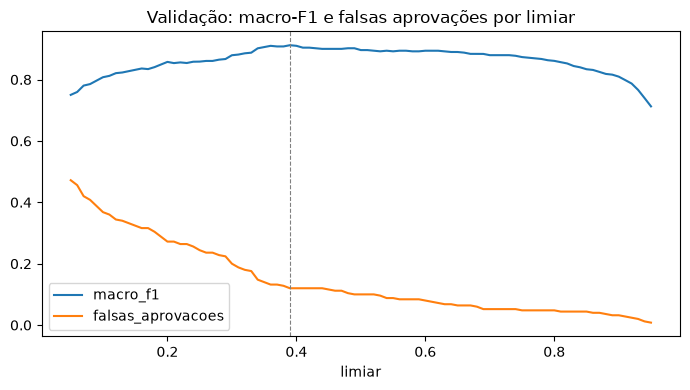

In [11]:
prob_validacao = modelo.predict_proba(X["validacao"])[:, 1]
limiares = np.round(np.arange(0.05, 0.96, 0.01), 2)
curva = pd.DataFrame({
    "limiar": limiares,
    "macro_f1": [f1_score(y["validacao"], (prob_validacao >= t).astype(int), average="macro") for t in limiares],
    "falsas_aprovacoes": [falsas_aprovacoes(y["validacao"], (prob_validacao >= t).astype(int)) for t in limiares],
})
LIMIAR = float(curva.loc[curva.macro_f1.idxmax(), "limiar"])
print("limiar escolhido na validação:", LIMIAR)

curva.plot(x="limiar", y=["macro_f1", "falsas_aprovacoes"], figsize=(7, 4), title="Validação: macro-F1 e falsas aprovações por limiar")
plt.axvline(LIMIAR, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

## 6. Resultado no teste

O conjunto de teste (2.448 pares) só é usado aqui, uma vez, depois de `C` e o limiar estarem fixados.

In [12]:
a_teste, y_teste = atributos["teste"], y["teste"]
prob_modelo = modelo.predict_proba(X["teste"])[:, 1]

metodos = {
    "NLI v0 sem treino": (decisao_nli(a_teste, "v0"), a_teste["v0_apoio"].to_numpy()),
    "NLI v1 sem treino": (decisao_nli(a_teste, "v1"), a_teste["v1_apoio"].to_numpy()),
    "Regra atual da VeritAI (v0)": (decisao_regra_atual(a_teste), a_teste["v0_apoio"].to_numpy()),
    "Modelo treinado": ((prob_modelo >= LIMIAR).astype(int), prob_modelo),
}

resultados = pd.DataFrame({nome: metricas(y_teste, pred, prob) for nome, (pred, prob) in metodos.items()}).T
resultados.round(3)

,acuracia,macro_f1,f1_apoia,precisao_apoia,revocacao_apoia,falsas_aprovacoes,brier,ece,auc
NLI v0 sem treino,0.791,0.791,0.790,0.793,0.787,0.205,0.157,0.118,0.882
NLI v1 sem treino,0.887,0.887,0.885,0.902,0.868,0.095,0.091,0.058,0.944
Regra atual da VeritAI (v0),0.798,0.797,0.783,0.847,0.728,0.132,0.157,0.118,0.882
Modelo treinado,0.897,0.897,0.900,0.878,0.923,0.128,0.075,0.018,0.960


In [13]:
macro = lambda yy, pp: f1_score(yy, pp, average="macro")
tabela = []
for nome, (pred, _) in metodos.items():
    f1_baixo, f1_alto = intervalo(y_teste, pred, macro)
    fa_baixo, fa_alto = intervalo(y_teste, pred, falsas_aprovacoes)
    tabela.append({
        "método": nome,
        "macro-F1": f"{macro(y_teste, pred):.3f} [{f1_baixo:.3f}, {f1_alto:.3f}]",
        "falsas aprovações": f"{falsas_aprovacoes(y_teste, pred):.3f} [{fa_baixo:.3f}, {fa_alto:.3f}]",
    })
pd.DataFrame(tabela).set_index("método")

,macro-F1,falsas aprovações
método,,
NLI v0 sem treino,"0.791 [0.776, 0.807]","0.205 [0.181, 0.227]"
NLI v1 sem treino,"0.887 [0.873, 0.899]","0.095 [0.080, 0.111]"
Regra atual da VeritAI (v0),"0.797 [0.782, 0.813]","0.132 [0.112, 0.151]"
Modelo treinado,"0.897 [0.885, 0.909]","0.128 [0.109, 0.147]"


Os intervalos acima são de cada método separado. Para comparar o modelo treinado com a melhor linha de base, o bootstrap abaixo sorteia os mesmos pares para os dois métodos e mede a diferença de macro-F1 em cada sorteio.

In [14]:
linhas_de_base = [nome for nome in metodos if nome != "Modelo treinado"]
melhor_base = max(linhas_de_base, key=lambda nome: resultados.loc[nome, "macro_f1"])
pred_modelo, pred_base = metodos["Modelo treinado"][0], metodos[melhor_base][0]

sorteio = np.random.default_rng(SEMENTE)
diferencas = []
for _ in range(1000):
    i = sorteio.integers(0, len(y_teste), len(y_teste))
    diferencas.append(macro(y_teste[i], pred_modelo[i]) - macro(y_teste[i], pred_base[i]))
baixo, alto = np.percentile(diferencas, [2.5, 97.5])
print(f"melhor linha de base: {melhor_base}")
print(f"diferença de macro-F1 (modelo - linha de base): {np.mean(diferencas):+.3f}, IC95 [{baixo:+.3f}, {alto:+.3f}]")

melhor linha de base: NLI v1 sem treino
diferença de macro-F1 (modelo - linha de base): +0.011, IC95 [-0.001, +0.022]


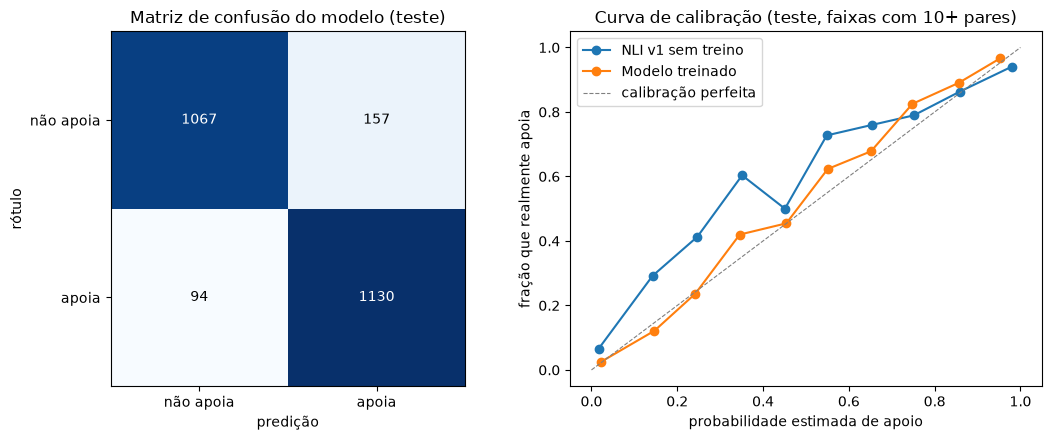

In [15]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5))

matriz = confusion_matrix(y_teste, pred_modelo)
eixos[0].imshow(matriz, cmap="Blues")
for (i, j), valor in np.ndenumerate(matriz):
    eixos[0].text(j, i, valor, ha="center", va="center", color="white" if valor > matriz.max() / 2 else "black")
eixos[0].set_xticks([0, 1], ["não apoia", "apoia"])
eixos[0].set_yticks([0, 1], ["não apoia", "apoia"])
eixos[0].set_xlabel("predição")
eixos[0].set_ylabel("rótulo")
eixos[0].set_title("Matriz de confusão do modelo (teste)")

for nome in ["NLI v1 sem treino", "Modelo treinado"]:
    prob = metodos[nome][1]
    indice = np.minimum((prob * 10).astype(int), 9)
    faixas = [i for i in range(10) if (indice == i).sum() >= 10]
    eixos[1].plot([prob[indice == i].mean() for i in faixas], [y_teste[indice == i].mean() for i in faixas], marker="o", label=nome)
eixos[1].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=0.8, label="calibração perfeita")
eixos[1].set_xlabel("probabilidade estimada de apoio")
eixos[1].set_ylabel("fração que realmente apoia")
eixos[1].set_title("Curva de calibração (teste, faixas com 10+ pares)")
eixos[1].legend()
plt.tight_layout()
plt.show()

### Onde o modelo erra

Alguns exemplos de falsas aprovações (o modelo disse "apoia" e o rótulo é "não apoia") e de apoios perdidos, com a maior confiança.

In [16]:
erros = conjuntos["teste"].assign(prob_apoio=prob_modelo.round(3), pred=pred_modelo)
pd.set_option("display.max_colwidth", 120)
print("Falsas aprovações:")
display(erros[(erros.apoia == 0) & (erros.pred == 1)].nlargest(5, "prob_apoio")[["trecho", "afirmacao", "prob_apoio"]])
print("Apoios perdidos:")
display(erros[(erros.apoia == 1) & (erros.pred == 0)].nsmallest(5, "prob_apoio")[["trecho", "afirmacao", "prob_apoio"]])

Falsas aprovações:


,trecho,afirmacao,prob_apoio
1512,Um homem jovem está fazendo um buraco em um pedaço de madeira,Um homem está fazendo um buraco em um pedaço de madeira,0.983
2248,Uma pessoa em uma jaqueta azul está pulando de um alto muro de cimento,Uma pessoa de jaqueta azul está pulando uma parede alta de cimento,0.975
1447,O homem está falando sobre o telefone,O homem está falando ao telefone,0.970
2164,Dois homens estão competindo em uma competição de pneus,Homens estão competindo em uma corrida de pneus,0.964
1990,Um gato branco está abrindo uma gaveta com suas patas e pulando para dentro,Um gato está abrindo uma gaveta e escalando para dentro,0.962


Apoios perdidos:


,trecho,afirmacao,prob_apoio
1232,Uma pessoa está cortando carne em pedaços,A pessoa não está fatiando um dente de alho em pedaços,0.003
2295,"Um homem, duas mulheres e uma menina estão andando na praia",Quatro pessoas estão caminhando,0.012
1079,O praticante de snowboard está girando no ar sobre um monte de neve,Alguém está pulando no ar em uma prancha,0.018
129,Três mulheres estão dançando,Uma pessoa está dançando,0.020
636,Um jovem menino está sentado de traje de banho e esperando pela próxima competição,Uma criança está sentada usando um equipamento de natação,0.020


## 7. Conferência no conjunto de contraste (não é medição)

O `eval/contraste.jsonl` tem 28 itens escritos à mão pela equipe, com pares em que uma mudança mínima na afirmação (negação, número, data, troca de papéis) inverte o resultado. Ele **não entrou no treino nem na escolha de C ou do limiar** e é pequeno e sintético demais para medir desempenho. Serve só para ver se o modelo percebe esse tipo de mudança. Aqui o rótulo `SUPPORTED` vira "apoia" e os outros viram "não apoia".

In [17]:
itens = [json.loads(linha) for linha in (RAIZ / "eval" / "contraste.jsonl").read_text(encoding="utf-8").splitlines() if linha.strip()]
contraste = pd.DataFrame({
    "id": [item["id"] for item in itens],
    "trecho": [" ".join(e["texto"] for e in item["evidencias"]) for item in itens],
    "afirmacao": [item["afirmacao"] for item in itens],
    "rotulo": [item["rotulo"] for item in itens],
})
prob_contraste = modelo.predict_proba(calcular_atributos(contraste.trecho, contraste.afirmacao)[COLUNAS].to_numpy())[:, 1]
contraste["prob_apoio"] = prob_contraste.round(3)
contraste["predicao"] = np.where(prob_contraste >= LIMIAR, "apoia", "não apoia")
contraste["acertou"] = (contraste.predicao == "apoia") == (contraste.rotulo == "SUPPORTED")
print(f"acertos: {contraste.acertou.sum()} de {len(contraste)}; "
      f"falsas aprovações: {((contraste.predicao == 'apoia') & (contraste.rotulo != 'SUPPORTED')).sum()} "
      f"de {(contraste.rotulo != 'SUPPORTED').sum()} itens que não apoiam")
contraste[["id", "afirmacao", "rotulo", "prob_apoio", "predicao", "acertou"]].style.hide(axis="index")

acertos: 24 de 28; falsas aprovações: 0 de 16 itens que não apoiam


id,afirmacao,rotulo,prob_apoio,predicao,acertou
P01a,As matrículas na rede municipal dobraram entre 2024 e 2025.,SUPPORTED,0.305000,não apoia,False
P01b,As matrículas na rede municipal não dobraram entre 2024 e 2025.,REFUTED,0.004000,não apoia,True
P02a,O preço da passagem de ônibus aumentou 25% neste ano.,SUPPORTED,0.081000,não apoia,False
P02b,O preço da passagem de ônibus dobrou neste ano.,REFUTED,0.184000,não apoia,True
P03a,"O município teve 8,2 mil casos de dengue em março.",SUPPORTED,0.851000,apoia,True
P03b,O município teve 82 mil casos de dengue em março.,REFUTED,0.153000,não apoia,True
P04a,A taxa de desemprego da região caiu 2 pontos percentuais no último ano.,SUPPORTED,0.281000,não apoia,False
P04b,A taxa de desemprego da região caiu 2% no último ano.,REFUTED,0.092000,não apoia,True
P05a,Os juros do financiamento estudantil subiram 1 ponto percentual.,SUPPORTED,0.392000,apoia,True
P05b,Os juros do financiamento estudantil subiram 10 pontos percentuais.,REFUTED,0.064000,não apoia,True


## 8. Salvando o modelo

O arquivo `.pkl` guarda o pipeline treinado (padronização + regressão logística), a lista e a ordem dos atributos, o limiar, os modelos de embedding e NLI de onde vêm os atributos, os hashes dos arquivos do ASSIN 2 e as métricas do teste. Para prever um par novo é preciso calcular os mesmos atributos, então os modelos dos perfis v0 e v1 também precisam estar disponíveis (são baixados do Hugging Face na primeira vez).

In [18]:
pacote = {
    "modelo": modelo,
    "atributos": COLUNAS,
    "limiar": LIMIAR,
    "classes": {0: "não apoia", 1: "apoia"},
    "perfis": {nome: {"embedding": perfil(nome)["embedding"], "nli": perfil(nome)["nli"]} for nome in PERFIS},
    "dados": {"conjunto": "nilc-nlp/assin2", "sha256": hashes},
    "C": busca.best_params_["logisticregression__C"],
    "metricas_teste": resultados.loc["Modelo treinado"].round(4).to_dict(),
    "versoes": {"python": platform.python_version(), "scikit-learn": sklearn.__version__, "torch": torch.__version__, "transformers": transformers.__version__},
    "criado_em": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "observacao": "Treinado no ASSIN 2 (frases genéricas, não notícias). Não substitui a calibração da VeritAI e não libera porcentagem.",
}
ARQUIVO_MODELO.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(pacote, ARQUIVO_MODELO)
print(ARQUIVO_MODELO.relative_to(RAIZ), f"{ARQUIVO_MODELO.stat().st_size / 1024:.1f} KB")

models\veritai_relacao_assin2.pkl 3.0 KB


## 9. Carregando o modelo salvo e usando

Exemplo de uso a partir do arquivo, como seria feito em outro notebook ou script. As frases abaixo são exemplos inventados só para mostrar a chamada.

In [19]:
carregado = joblib.load(ARQUIVO_MODELO)


def prever(trecho, afirmacao):
    entrada = calcular_atributos([trecho], [afirmacao])[carregado["atributos"]].to_numpy()
    probabilidade = float(carregado["modelo"].predict_proba(entrada)[0, 1])
    return {"prob_apoio": round(probabilidade, 3), "resultado": carregado["classes"][int(probabilidade >= carregado["limiar"])]}


exemplos = [
    ("A biblioteca municipal passou a abrir aos domingos a partir de março.", "A biblioteca municipal abre aos domingos."),
    ("A biblioteca municipal passou a abrir aos domingos a partir de março.", "A biblioteca municipal não abre aos domingos."),
    ("A biblioteca municipal passou a abrir aos domingos a partir de março.", "A prefeitura reformou a biblioteca municipal."),
]
pd.DataFrame([{"trecho": t, "afirmacao": a, **prever(t, a)} for t, a in exemplos])

,trecho,afirmacao,prob_apoio,resultado
0,A biblioteca municipal passou a abrir aos domingos a partir de março.,A biblioteca municipal abre aos domingos.,0.930,apoia
1,A biblioteca municipal passou a abrir aos domingos a partir de março.,A biblioteca municipal não abre aos domingos.,0.006,não apoia
2,A biblioteca municipal passou a abrir aos domingos a partir de março.,A prefeitura reformou a biblioteca municipal.,0.053,não apoia


## 10. Conclusões

Os números abaixo são os do teste (2.448 pares), com intervalo de 95% por bootstrap.

**O modelo treinado não é claramente melhor que o NLI da v1 em classificação.** O macro-F1 foi 0,897 [0,885; 0,909], contra 0,887 [0,873; 0,899] do NLI da v1 sem treino, a melhor linha de base. Na comparação pareada, a diferença foi de +0,011 com intervalo [-0,001; +0,022], que encosta no zero. Não dá para afirmar que o treino melhorou a classificação.

**Nas falsas aprovações, o modelo ficou pior que a v1:** 0,128 [0,109; 0,147] contra 0,095 [0,080; 0,111]. O limiar foi escolhido na validação pelo maior macro-F1 (0,39), e um limiar baixo aprova mais. A regra do projeto diz que um modelo novo só substitui o atual se tiver macro-F1 maior **e** falsas aprovações iguais ou menores. Com esse limiar, o modelo treinado **não** passa nesse critério.

**As melhores estimativas pontuais do modelo estão na probabilidade.** Brier 0,075 contra 0,091, ECE 0,018 contra 0,058 e AUC 0,960 contra 0,944. Não calculamos intervalo de confiança para essas três métricas, então a comparação é só pelos valores pontuais. Na curva de calibração, a linha do modelo fica perto da diagonal. A do NLI da v1 fica acima dela entre 10% e 60%: nessa faixa, o mDeBERTa subestima o apoio (quando ele diz 35%, cerca de 60% dos pares apoiam). Com o modelo treinado, a probabilidade estimada fica mais próxima da frequência real neste conjunto. É o tipo de propriedade de que a VeritAI precisa antes de mostrar qualquer porcentagem, embora aqui ela só tenha sido verificada no ASSIN 2.

**A regra atual da VeritAI ficou bem abaixo.** Com os limiares herdados do protótipo sobre a v0, o macro-F1 foi 0,797 e as falsas aprovações 0,132. Isso reforça duas coisas que já estavam no planejamento: os limiares do `config.json` precisam ser definidos com dados rotulados, e a v1 é bem melhor que a v0 nesta tarefa (0,887 contra 0,791 de macro-F1 sem treino).

**O que o modelo aprendeu.** Os maiores pesos positivos são a probabilidade de apoio do NLI da v1 e a similaridade da v0. Os maiores pesos negativos são a probabilidade de contradição da v1 e a negação presente em só um dos lados. O apoio do NLI da v0 quase não pesa, porque repete o que a v1 já informa.

**Erros.** Entre as falsas aprovações mais confiantes aparecem pares quase idênticos que o ASSIN 2 marca como "não apoia" (por exemplo, "homem jovem" → "homem"), alguns de rótulo discutível. Entre os apoios perdidos aparecem generalizações e contagens ("três mulheres" → "uma pessoa"; "um homem, duas mulheres e uma menina" → "quatro pessoas").

**Conjunto de contraste (só conferência).** O modelo acertou 24 de 28 itens e não aprovou nenhum dos 16 itens que não apoiam. Os 4 erros foram todos apoios perdidos que dependem de conta ou de paráfrase com negação: "dobraram" (12 mil → 24 mil), "aumentou 25%", "pontos percentuais" e "continuará liberada". Isso é coerente com o ASSIN 2 não ter números: o modelo nunca viu esse tipo de caso no treino.

### Limitações

- O ASSIN 2 tem frases que descrevem cenas, sem números, datas, nomes próprios ou linguagem de notícia. Um bom resultado aqui não garante bom resultado em notícias.
- O rótulo é binário: "contradiz" e "não tem informação" ficam juntos em "não apoia", enquanto a VeritAI usa quatro classes.
- Há 11 pares iguais entre treino e validação. O modelo já tinha visto esses pares no treino, então a validação pode ter ficado um pouco mais fácil do que deveria, e o limiar escolhido nela (0,39) pode estar otimista. Entre treino e teste não há nenhum par igual, mas muitas frases de trecho se repetem entre as partes, por construção do conjunto.
- Foi uma única divisão e uma única semente.
- O `.pkl` guarda só a regressão logística (3 KB). Para prever, é preciso calcular os atributos com os modelos de embedding e NLI dos perfis v0 e v1.
- Este conjunto de teste já foi usado. Qualquer nova escolha de limiar ou de modelo precisa de outro teste.

### Próximos passos

1. Escolher o limiar na validação com uma restrição de falsas aprovações, seguindo o critério do projeto, e avaliar num teste novo.
2. Montar o conjunto rotulado de notícias em português (afirmação, trecho e quatro classes), separado por evento, período e fonte.
3. Ajustar o `xlm-roberta-base` (V2) nesse conjunto, com GPU.
4. Calibrar num conjunto próprio de calibração e só então liberar a porcentagem no serviço.